# 📑 Day 28 - Sentiment Analysis of Amazon Product Reviews
### Classifying the sentiment of Amazon product reviews using Bag-of-Words and TF-IDF representations with Multinomial Naive Bayes classifier

In [22]:
import time
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib

In [2]:
train_path = Path("train.ft.txt")
test_path  = Path("test.ft.txt")

In [3]:
# parse train
train_rows = []
with train_path.open("r", encoding="utf8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        m = re.match(r'^\s*__label__(\d+)\s+(.+)$', line, re.IGNORECASE)
        if not m:
            continue
        lbl = int(m.group(1))
        text = m.group(2).strip()
        if lbl == 2:
            label = 1   # positive
        elif lbl == 1:
            label = 0   # negative
        else:
            continue    # skip any unexpected labels
        train_rows.append((label, text))

In [4]:
# parse test
test_rows = []
with test_path.open("r", encoding="utf8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        m = re.match(r'^\s*__label__(\d+)\s+(.+)$', line, re.IGNORECASE)
        if not m:
            continue
        lbl = int(m.group(1))
        text = m.group(2).strip()
        if lbl == 2:
            label = 1
        elif lbl == 1:
            label = 0
        else:
            continue
        test_rows.append((label, text))

In [5]:
df_train = pd.DataFrame(train_rows, columns=["label","text"])
df_test  = pd.DataFrame(test_rows,  columns=["label","text"])
print("Train size:", len(df_train), "\nLabel counts:\n", df_train['label'].value_counts())
print("\nTest  size:", len(df_test),  "\nLabel counts:\n", df_test['label'].value_counts())

Train size: 3600000 
Label counts:
 label
1    1800000
0    1800000
Name: count, dtype: int64

Test  size: 400000 
Label counts:
 label
1    200000
0    200000
Name: count, dtype: int64


In [6]:
# simple cleaning
_clean_re_http = re.compile(r'http\S+')
_clean_re_html = re.compile(r'<[^>]+>')
_clean_re_non_alnum = re.compile(r'[^a-z0-9\s]')
def _clean(s):
    s = str(s).lower()
    s = _clean_re_http.sub(' ', s)
    s = _clean_re_html.sub(' ', s)
    s = _clean_re_non_alnum.sub(' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df_train['clean'] = df_train['text'].apply(_clean)
df_test['clean']  = df_test['text'].apply(_clean)

In [7]:
df_train.head()

,label,text,clean
0,1,Stuning even for the non-gamer: This sound tra...,stuning even for the non gamer this sound trac...
1,1,The best soundtrack ever to anything.: I'm rea...,the best soundtrack ever to anything i m readi...
2,1,Amazing!: This soundtrack is my favorite music...,amazing this soundtrack is my favorite music o...
3,1,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack i truly like this soundtr...
4,1,"Remember, Pull Your Jaw Off The Floor After He...",remember pull your jaw off the floor after hea...


In [8]:
df_test.head()

,label,text,clean
0,1,Great CD: My lovely Pat has one of the GREAT v...,great cd my lovely pat has one of the great vo...
1,1,One of the best game music soundtracks - for a...,one of the best game music soundtracks for a g...
2,0,Batteries died within a year ...: I bought thi...,batteries died within a year i bought this cha...
3,1,"works fine, but Maha Energy is better: Check o...",works fine but maha energy is better check out...
4,1,Great for the non-audiophile: Reviewed quite a...,great for the non audiophile reviewed quite a ...


In [9]:
X_train = df_train['clean'].values
y_train = df_train['label'].values
X_test  = df_test['clean'].values
y_test  = df_test['label'].values

In [10]:
print("FAST: TF-IDF (max_features=5k, unigrams) + MultinomialNB")
t0 = time.time()
pipe_fast = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,1), stop_words='english')),
    ("clf", MultinomialNB()),
])
pipe_fast.fit(X_train, y_train)
pred_fast = pipe_fast.predict(X_test)
t1 = time.time()
print("Time (s):", round(t1-t0, 2))
print("Accuracy:", round(accuracy_score(y_test, pred_fast), 4))
print(classification_report(y_test, pred_fast))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_fast))
print("ROC AUC:", round(roc_auc_score(y_test, pipe_fast.predict_proba(X_test)[:,1]), 4))

FAST: TF-IDF (max_features=5k, unigrams) + MultinomialNB
Time (s): 1615.05
Accuracy: 0.8397
              precision    recall  f1-score   support

           0       0.84      0.84      0.84    200000
           1       0.84      0.84      0.84    200000

    accuracy                           0.84    400000
   macro avg       0.84      0.84      0.84    400000
weighted avg       0.84      0.84      0.84    400000

Confusion matrix:
 [[167818  32182]
 [ 31918 168082]]
ROC AUC: 0.92


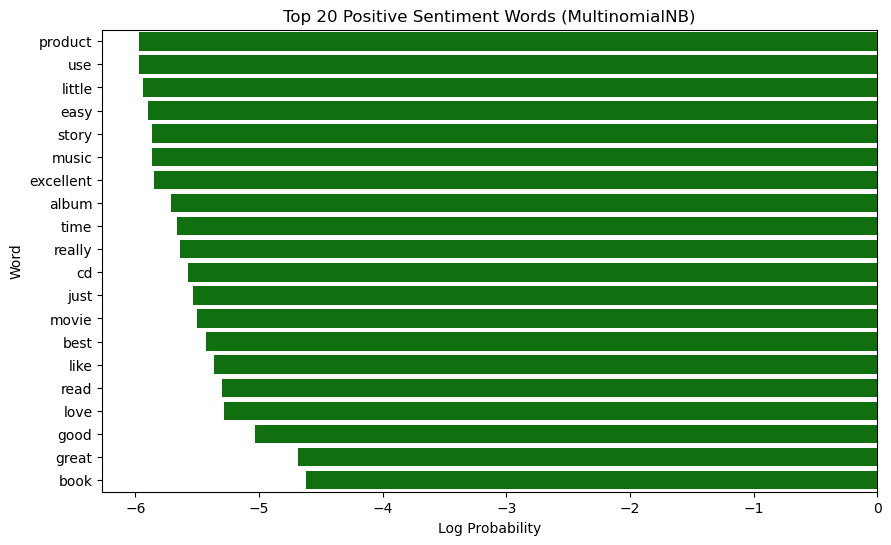

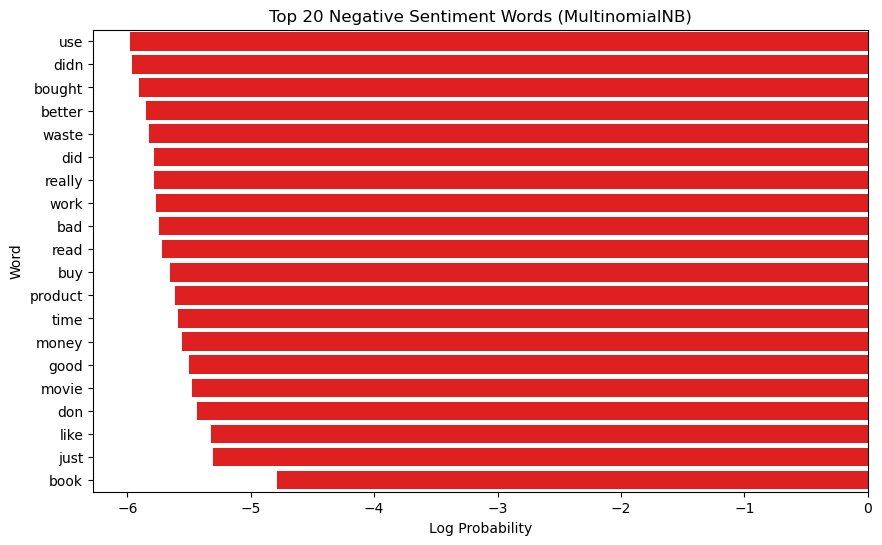

In [23]:
# Extract feature names from TF-IDF
feature_names = pipe_fast.named_steps['tfidf'].get_feature_names_out()

# Get log probabilities of each class
log_prob = pipe_fast.named_steps['clf'].feature_log_prob_

# Identify top 20 features for positive reviews
top_pos_idx = np.argsort(log_prob[1])[-20:]
top_pos_words = feature_names[top_pos_idx]
top_pos_scores = log_prob[1][top_pos_idx]

# Identify top 20 features for negative reviews
top_neg_idx = np.argsort(log_prob[0])[-20:]
top_neg_words = feature_names[top_neg_idx]
top_neg_scores = log_prob[0][top_neg_idx]

# Create dataframes for plotting
df_pos = pd.DataFrame({'word': top_pos_words, 'importance': top_pos_scores})
df_neg = pd.DataFrame({'word': top_neg_words, 'importance': top_neg_scores})

# Plot Positive Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(data=df_pos.sort_values('importance', ascending=True),
            x='importance', y='word', color='green')
plt.title("Top 20 Positive Sentiment Words (MultinomialNB)")
plt.xlabel("Log Probability")
plt.ylabel("Word")
plt.show()

# Plot Negative Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(data=df_neg.sort_values('importance', ascending=True),
            x='importance', y='word', color='red')
plt.title("Top 20 Negative Sentiment Words (MultinomialNB)")
plt.xlabel("Log Probability")
plt.ylabel("Word")
plt.show()

In [11]:
# save TF-IDF model
joblib.dump(pipe_fast, "tfidf_logreg_amazon_label12.joblib")
print("Saved TF-IDF model to tfidf_logreg_amazon_label12.joblib")

Saved TF-IDF model to tfidf_logreg_amazon_label12.joblib


In [13]:
# quick demo predictions
samples = ["This product is fantastic, I love it!", "Awful. Broke after one use. Do not buy."]
print("Sample predictions (TF-IDF):")
for s in samples:
    cs = _clean(s)
    p = pipe_fast.predict([cs])[0]
    prob = pipe_fast.predict_proba([cs])[0,1]
    print(f"  '{s}' -> Pred: {p}, positive_prob={prob:.4f}")

Sample predictions (TF-IDF):
  'This product is fantastic, I love it!' -> Pred: 1, positive_prob=0.8658
  'Awful. Broke after one use. Do not buy.' -> Pred: 0, positive_prob=0.0449
